In [5]:
import pandas as pd

#wczytanie pliku
df = pd.read_excel('master_listings.xlsx')

#podgląd kolumn
print("kolumny:")
print(df.columns.tolist())

#pierwsze wiersze
display(df.head())


kolumny:
['_id', 'agency__id', 'agency_city', 'agency_county', 'agency_name', 'agency_otodom_id', 'agency_postal_code', 'agency_province', 'agency_street', 'area', 'auction_type', 'building_build_year', 'building_floors', 'building_type', 'created_at', 'description', 'developer_id', 'estate_agency', 'extras', 'floor', 'heating', 'link', 'localization_city', 'localization_county', 'localization_district', 'localization_latitude', 'localization_longitude', 'localization_province', 'localization_street', 'market_type', 'offered_by', 'otodom_id', 'photo_urls', 'price', 'price_per_meter', 'promoted', 'property_type', 'rent', 'construction_status', 'rooms', 'security_types', 'title']


,_id,agency__id,agency_city,agency_county,agency_name,agency_otodom_id,agency_postal_code,agency_province,agency_street,area,...,photo_urls,price,price_per_meter,promoted,property_type,rent,construction_status,rooms,security_types,title
0,69dff390bb6960888b1b9d23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,107.20,...,https://ireland.apollo.olxcdn.com/v1/files/eyJ...,1640160.0,15300.0,False,flat,NaN,to_completion,5,NaN,5-pokojowe mieszkanie 107m2 + ogródek Bezpośre...
1,69dff390bb6960888b1b9d24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,107.20,...,https://ireland.apollo.olxcdn.com/v1/files/eyJ...,1640160.0,15300.0,False,flat,NaN,to_completion,5,NaN,5-pokojowe mieszkanie 107m2 + ogródek Bez Prow...
2,69dff391bb6960888b1b9d25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,107.20,...,https://ireland.apollo.olxcdn.com/v1/files/eyJ...,1640160.0,15300.0,False,flat,NaN,to_completion,5,NaN,5-pokojowe mieszkanie 107m2 + ogródek
3,69dff39bbb6960888b1b9d26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.77,...,https://ireland.apollo.olxcdn.com/v1/files/eyJ...,485975.0,17500.0,False,flat,NaN,to_completion,1,NaN,1-pokojowe mieszkanie 27m2 + ogródek Bezpośrednio
4,69dff39bbb6960888b1b9d27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.66,...,https://ireland.apollo.olxcdn.com/v1/files/eyJ...,489582.0,17700.0,False,flat,NaN,to_completion,1,NaN,1-pokojowe mieszkanie 27m2 + loggia


Najczęstsza liczba pokojów (moda): 2

Udział w rynku:
Primary market: 69.09%
Secondary market: 30.91%


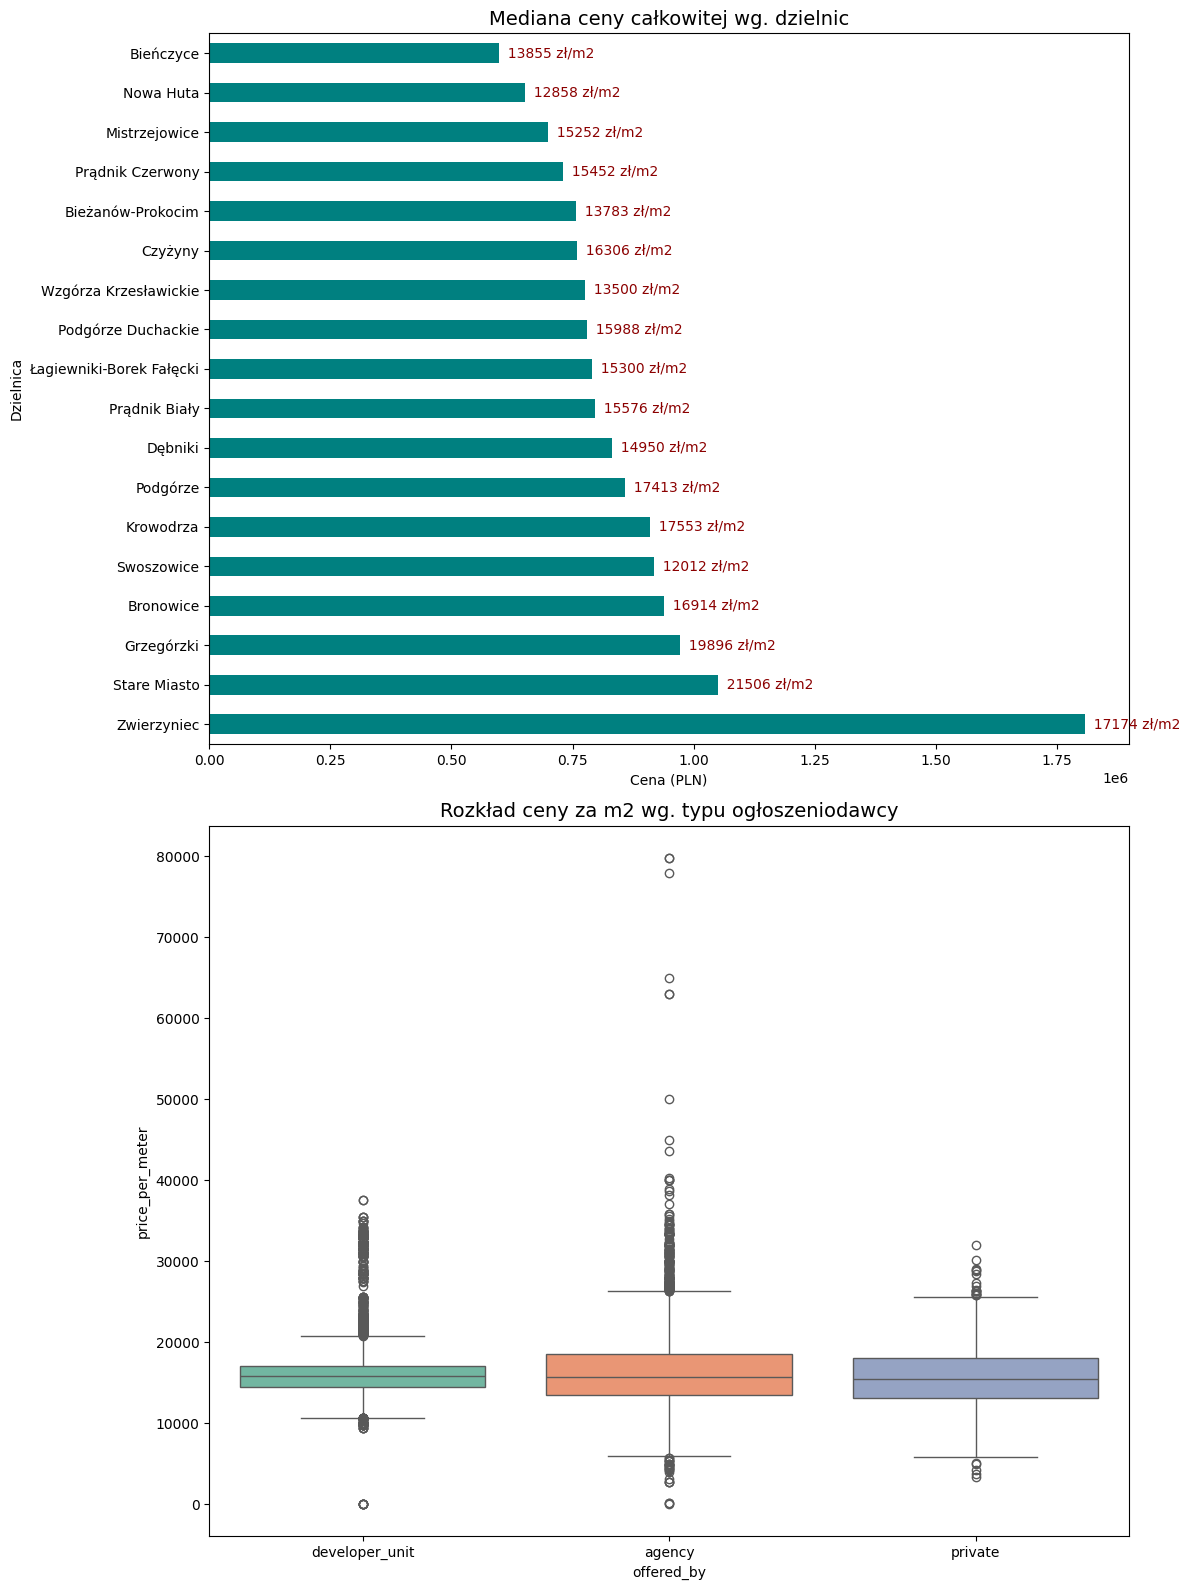

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# MAPOWANIE DZIELNIC
mapping = {
    'Stare Miasto': ['Stare Miasto', 'Kazimierz', 'Nowy Świat', 'Kleparz', 'Piasek', 'Wawel', 'Wesoła', 'Centrum'],
    'Grzegórzki': ['Grzegórzki', 'Dąbie', 'Olsza', 'Rakowice', 'Wesoła'],
    'Prądnik Czerwony': ['Prądnik Czerwony', 'Olsza', 'Rakowice', 'Ugorek', 'Wieczysta'],
    'Prądnik Biały': ['Prądnik Biały', 'Górka Narodowa', 'Witkowice', 'Azory', 'Żabiniec', 'Tonie', 'Krowodrza Górka'],
    'Krowodrza': ['Krowodrza', 'Łobzów', 'Nowa Wieś', 'Stara Krowodrza', 'Cichy Kącik', 'Czarna Wieś'],
    'Bronowice': ['Bronowice', 'Bronowice Małe', 'Bronowice Wielkie', 'Mydlniki'],
    'Zwierzyniec': ['Zwierzyniec', 'Salwator', 'Wola Justowska', 'Olszanica', 'Przegorzały', 'Bielany', 'Chełm', 'Zakamycze', 'Półwsie Zwierzynieckie'],
    'Dębniki': ['Dębniki', 'Ruczaj', 'Pychowice', 'Tyniec', 'Kostrze', 'Bodzów', 'Skotniki', 'Zakrzówek', 'Ludwinów', 'Sidzina'],
    'Łagiewniki-Borek Fałęcki': ['Łagiewniki-Borek Fałęcki', 'Łagiewniki', 'Borek Fałęcki', 'Cegielniana'],
    'Swoszowice': ['Swoszowice', 'Opatkowice', 'Kliny-Zacisze', 'Wróblowice', 'Rajsko', 'Jugowice'],
    'Podgórze Duchackie': ['Podgórze Duchackie', 'Kurdwanów', 'Wola Duchacka', 'Piaski Wielkie', 'Kozłówek'],
    'Bieżanów-Prokocim': ['Bieżanów-Prokocim', 'Bieżanów', 'Prokocim', 'Złocień', 'Rżąka'],
    'Podgórze': ['Podgórze', 'Płaszów', 'Stare Podgórze', 'Zabłocie', 'Rybitwy', 'Przewóz', 'Bonarka', 'Mateczny'],
    'Czyżyny': ['Czyżyny'],
    'Mistrzejowice': ['Mistrzejowice', 'Mistrzejowice Nowe'],
    'Bieńczyce': ['Bieńczyce'],
    'Nowa Huta': ['Nowa Huta', 'Mogiła', 'Branice', 'Pleszów', 'Ruszcza', 'Przylasek Rusiecki', 'Wolica', 'Lubocza', 'Wadów', 'Kościelniki'],
    'Wzgórza Krzesławickie': ['Wzgórza Krzesławickie', 'Grębałów', 'Zesławice', 'Kantorowice', 'Łuczanowice']
}

rev_mapping = {v: k for k, values in mapping.items() for v in values}
df['district_final'] = df['localization_district'].map(rev_mapping).fillna('Inne')

# na numery
df['price_per_meter'] = pd.to_numeric(df['price_per_meter'], errors='coerce')
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# kolumna rooms - stringi na numery
df['rooms_clean'] = pd.to_numeric(df['rooms'].astype(str).str.extract(r'(\d+)', expand=False), errors='coerce')

# 1 moda ilości pokojów
mode_rooms = df['rooms_clean'].mode()[0]
print(f"Najczęstsza liczba pokojów (moda): {int(mode_rooms)}")

# 2 procent rynku pierwotnego i wtórnego
market_share = df['market_type'].value_counts(normalize=True) * 100
print("\nUdział w rynku:")
print(f"Primary market: {market_share.get('primary', 0):.2f}%")
print(f"Secondary market: {market_share.get('secondary', 0):.2f}%")

# WYKRESY
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 16))

# 3 poziomy bar chart - district vs median price
district_stats = df[df['district_final'] != 'Inne'].groupby('district_final').agg({
    'price': 'median',
    'price_per_meter': 'median'
}).sort_values('price', ascending=False)

district_stats['price'].plot(kind='barh', ax=ax1, color='teal')
ax1.set_title('Mediana ceny całkowitej wg. dzielnic', fontsize=14)
ax1.set_xlabel('Cena (PLN)')
ax1.set_ylabel('Dzielnica')

for i, (p, ppm) in enumerate(zip(district_stats['price'], district_stats['price_per_meter'])):
    if pd.notnull(p) and pd.notnull(ppm):
        ax1.text(p, i, f'  {int(ppm)} zł/m2', va='center', fontsize=10, color='darkred')

# 4 boxplot - price_per_m grouped by offered_by
sns.boxplot(x='offered_by', y='price_per_meter', data=df, ax=ax2, palette='Set2', hue='offered_by', legend=False)
ax2.set_title('Rozkład ceny za m2 wg. typu ogłoszeniodawcy', fontsize=14)

plt.tight_layout()
plt.show()


In [ ]:
#podgląd "dzielnic"
print(df['localization_district'].unique().tolist())

['Łagiewniki-Borek Fałęcki', 'Podgórze', 'Czyżyny', 'Płaszów', 'Bieżanów-Prokocim', 'Stare Miasto', 'Salwator', 'Krowodrza', 'Borek Fałęcki', nan, 'Wola Justowska', 'Dębniki', 'Nowa Huta', 'Grzegórzki', 'Zwierzyniec', 'Mistrzejowice', 'Prądnik Czerwony', 'Górka Narodowa', 'Stare Podgórze', 'Prądnik Biały', 'Podgórze Duchackie', 'Nowy Świat', 'Ludwinów', 'Bronowice', 'Zabłocie', 'Śródmieście', 'Swoszowice', 'Wzgórza Krzesławickie', 'Bronowice Małe', 'Stara Krowodrza', 'Olszanica', 'Mogiła', 'Przegorzały', 'Opatkowice', 'Bronowice Wielkie', 'Tyniec', 'Kliny-Zacisze', 'Kurdwanów', 'Bieńczyce', 'Łobzów', 'Tonie', 'Wola Duchacka', 'Ruczaj', 'Kazimierz', 'Mistrzejowice Nowe', 'Pychowice', 'Olsza', 'Żabiniec', 'Kleparz', 'Przewóz', 'Złocień', 'Centrum', 'Cegielniana', 'Rakowice', 'Łagiewniki', 'Krowodrza Górka', 'Azory', 'Rybitwy', 'Półwsie Zwierzynieckie', 'Mydlniki', 'Piaski Wielkie', 'Wróblowice', 'Nowa Wieś', 'Warszawskie', 'Ugorek', 'Czarna Wieś', 'Bieżanów', 'Wolica', 'Zakrzówek', 'Krzy